# Feature Engineering: Proximity Profile

This notebook explores the new **`proximity_profile_norm`** feature and compares it against
existing features for the touching/non-touching classification task.

## Feature Definition

Given two channels h1 and h2 that share a confluence C:

1. Trace the full path from each head to C
2. Sample `n_samples` evenly-spaced points along each path (by arc-length)
3. Compute Euclidean distance between the i-th point on path 1 and the i-th point on path 2
4. `proximity_mean_m` = mean of the `n_samples` distances (metres)
5. `proximity_max_m` = max of the `n_samples` distances (metres)
6. `proximity_profile_norm` = `proximity_mean_m / proximity_max_m` ∈ [0, 1]
   - **≈ 1.0**: channels run nearly parallel (uniform separation)
   - **< 1.0**: channels converge strongly toward the confluence

**Hypothesis:** touching-basin pairs tend to run closer together for a larger fraction
of their length → lower `proximity_profile_norm` (strong convergence).

**Notebook structure:**
1. Recompute proximity features on one basin (Inyo) to sanity-check the implementation
2. Load master dataset, explore feature distributions by class
3. Compute KS statistics for all features
4. Correlation check vs existing features
5. Quick retrain comparison: baseline vs +proximity_profile_norm

**n_samples sensitivity:** Run section 6 to sweep n_samples and see how KS stat changes.

## 0. Imports

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupKFold, cross_validate
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path("/Users/guypi/Projects/channel-heads")
RANDOM_STATE = 42
N_SAMPLES = 10  # ← change this to experiment (try 5, 10, 20)

## 1. Sanity Check: Recompute Proximity on Inyo Basin

Run `GeometricFeaturesAnalyzer` on Inyo with the new feature and inspect the output.

In [2]:
import numpy as np_
import topotoolbox as tt3
from channel_heads import (
    CouplingAnalyzer,
    GeometricFeaturesAnalyzer,
    LengthwiseAsymmetryAnalyzer,
    EXAMPLE_DEMS,
    first_meet_pairs_for_outlet,
    get_basin_config,
    get_output_dir,
    merge_coupling_and_asymmetry,
    merge_geometric_features,
)
from channel_heads.stream_utils import outlet_node_ids_from_streampoi

basin = "inyo"
config = get_basin_config(basin)
dem_path = EXAMPLE_DEMS.get(basin)

if dem_path is None or not dem_path.exists():
    print(f"DEM for '{basin}' not found at {dem_path}. Skipping sanity check.")
    SANITY_OK = False
else:
    dem = tt3.read_tif(str(dem_path))
    dem.z[dem.z < config["z_th"]] = float("nan")

    fd = tt3.FlowObject(dem)
    s = tt3.StreamObject(fd, threshold=300)

    print(f"Basin: {basin}")
    print(f"Stream nodes: {len(s.node_indices[0]):,}")
    SANITY_OK = True

Basin: inyo
Stream nodes: 1,474


In [3]:
if SANITY_OK:
    coupling_an = CouplingAnalyzer(fd, s, dem)
    asym_an = LengthwiseAsymmetryAnalyzer(s, dem, lat=config["lat"])
    node_orders = s.streamorder()  # Strahler order per node
    geom_an = GeometricFeaturesAnalyzer(
        s, dem, lat=config["lat"], n_proximity_samples=N_SAMPLES, node_orders=node_orders
    )

    outlets = outlet_node_ids_from_streampoi(s)
    print(f"Processing {len(outlets)} outlets with n_proximity_samples={N_SAMPLES} ...")

    all_results = []
    for outlet_id in outlets:
        pairs, _ = first_meet_pairs_for_outlet(s, outlet_id)
        coupling_df = coupling_an.evaluate_pairs_for_outlet(outlet_id, pairs)
        asym_df = asym_an.evaluate_pairs_for_outlet(outlet_id, pairs)
        geom_df = geom_an.evaluate_pairs_for_outlet(outlet_id, pairs, asymmetry_df=asym_df)
        combined = merge_coupling_and_asymmetry(coupling_df, asym_df)
        combined = merge_geometric_features(combined, geom_df)
        all_results.append(combined)
        coupling_an.clear_cache()

    inyo_df = pd.concat(all_results, ignore_index=True)
    print(f"\nRows: {len(inyo_df):,}")
    print(f"Proximity NaN rate: {inyo_df['proximity_profile_norm'].isna().mean():.1%}")
    print(inyo_df[["touching", "proximity_mean_m", "proximity_max_m", "proximity_profile_norm"]].describe())

Processing 28 outlets with n_proximity_samples=10 ...

Rows: 15
Proximity NaN rate: 0.0%
       proximity_mean_m  proximity_max_m  proximity_profile_norm
count         15.000000        15.000000               15.000000
mean        1225.871982      2103.076307                0.591093
std          573.091597      1031.113910                0.047593
min          273.282564       496.608911                0.535948
25%          956.217830      1494.702240                0.558928
50%         1354.235019      2370.119178                0.586469
75%         1481.569148      2581.586267                0.612482
max         2330.239250      4145.850037                0.695143


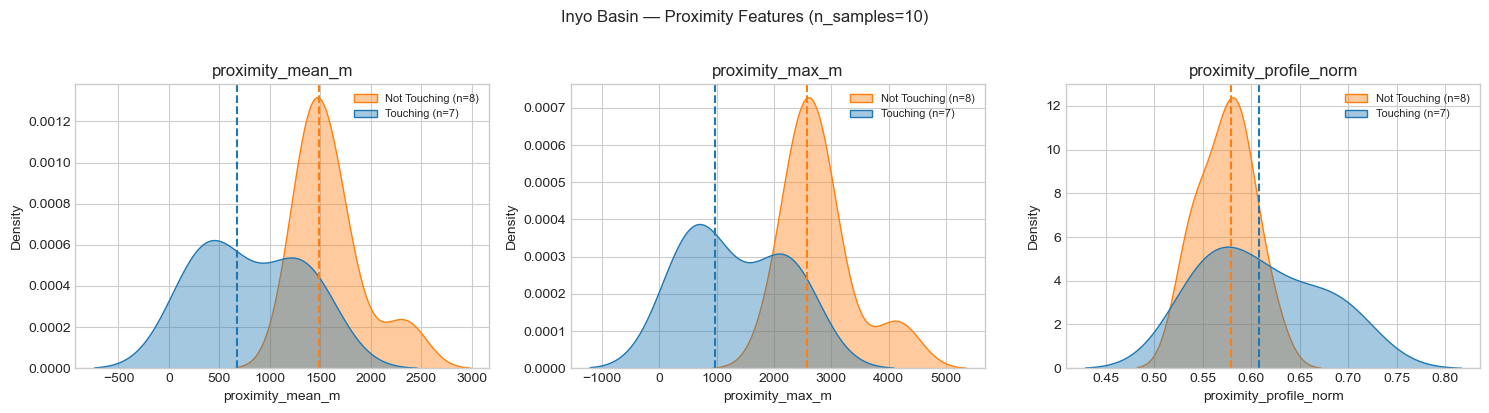

In [4]:
if SANITY_OK:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, ["proximity_mean_m", "proximity_max_m", "proximity_profile_norm"]):
        for cls, label, color in [(False, "Not Touching", "#ff7f0e"), (True, "Touching", "#1f77b4")]:
            data = inyo_df.loc[inyo_df["touching"] == cls, col].dropna()
            if len(data) >= 2:
                sns.kdeplot(data, ax=ax, fill=True, alpha=0.4, color=color, label=f"{label} (n={len(data):,})")
                ax.axvline(data.median(), color=color, linestyle="--", lw=1.5)
        ax.set_title(col)
        ax.legend(fontsize=8)
    plt.suptitle(f"Inyo Basin — Proximity Features (n_samples={N_SAMPLES})", y=1.02)
    plt.tight_layout()
    plt.show()

## 2. Load Master Dataset

In [5]:
data_path = PROJECT_ROOT / "data" / "results" / "master_dataset_v2.csv"
df = pd.read_csv(data_path, low_memory=False)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"Basins: {sorted(df['basin'].unique())}")
print(f"Class balance: {df['touching'].mean():.1%} touching")

# Check if proximity columns already exist in master dataset
prox_cols = ["proximity_mean_m", "proximity_max_m", "proximity_profile_norm"]
has_prox = all(c in df.columns for c in prox_cols)
print(f"\nProximity columns in master dataset: {has_prox}")
if has_prox:
    print(f"NaN rate: {df['proximity_profile_norm'].isna().mean():.1%}")

Loaded 5,922 rows, 23 columns
Basins: ['calnalpine', 'daqing', 'finisterre', 'humboldt', 'inyo', 'kammanasie', 'luliang', 'panamint', 'sakhalin', 'sierramadre', 'sierranevadaspain', 'taiwan', 'toano', 'troodos', 'tsugaru', 'vallefertil', 'yoro']
Class balance: 39.1% touching

Proximity columns in master dataset: True
NaN rate: 0.0%


In [6]:
# If proximity columns missing from master dataset, use Inyo results for exploration.
# (Run notebooks/ml/00_full_pipeline.ipynb to regenerate master_dataset_v2.csv with proximity cols)
if not has_prox:
    print('Proximity columns not found in master dataset.')
    print('Using Inyo basin results for exploration.')
    if SANITY_OK:
        df_explore = inyo_df.copy()
        # Add basin column so section 5 (retrain) works
        df_explore["basin"] = basin
    else:
        df_explore = pd.DataFrame()
else:
    df_explore = df.copy()


## 3. Feature Distributions by Class

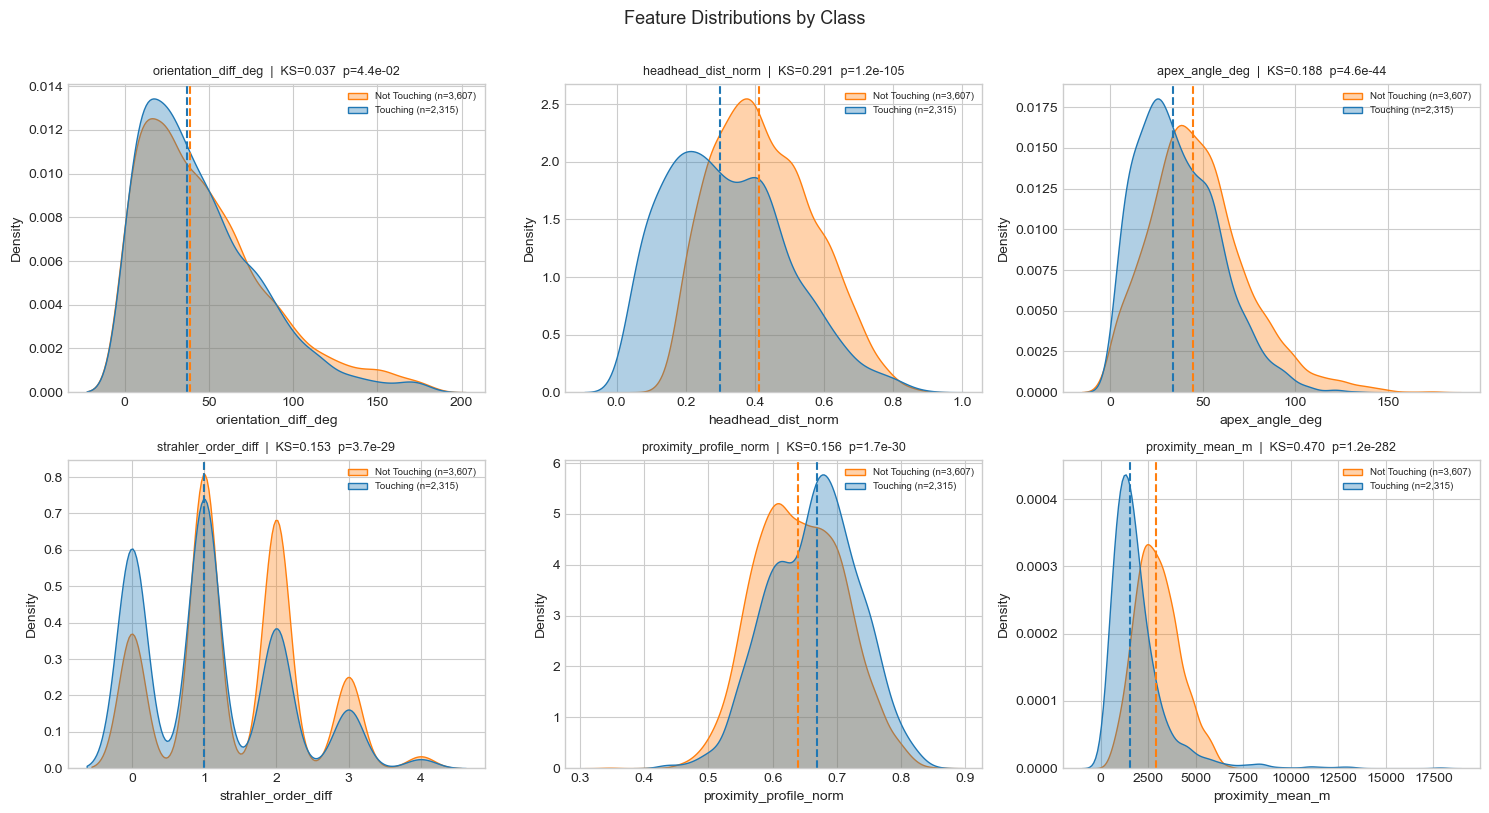


=== KS Separability (higher = better) ===
               feature  KS_stat   KS_p
      proximity_mean_m   0.4703 0.0000
    headhead_dist_norm   0.2908 0.0000
        apex_angle_deg   0.1881 0.0000
proximity_profile_norm   0.1562 0.0000
   strahler_order_diff   0.1527 0.0000
  orientation_diff_deg   0.0367 0.0438


In [7]:
ALL_FEATURES = [
    "orientation_diff_deg",
    "headhead_dist_norm",
    "apex_angle_deg",
    "strahler_order_diff",
    "proximity_profile_norm",   # ← new
    "proximity_mean_m",         # ← new (scale-dependent, for reference)
]

available = [f for f in ALL_FEATURES if f in df_explore.columns]
missing = set(ALL_FEATURES) - set(available)
if missing:
    print(f"Missing features: {missing}")

PALETTE = {False: "#ff7f0e", True: "#1f77b4"}

n_feats = len(available)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

ks_rows = []
for i, feat in enumerate(available):
    ax = axes[i]
    data_0 = df_explore.loc[df_explore["touching"] == False, feat].dropna()
    data_1 = df_explore.loc[df_explore["touching"] == True, feat].dropna()

    for cls, data in [(False, data_0), (True, data_1)]:
        if len(data) >= 2:
            sns.kdeplot(data, ax=ax, fill=True, alpha=0.35, color=PALETTE[cls],
                        label=f"{'Touching' if cls else 'Not Touching'} (n={len(data):,})")
            ax.axvline(data.median(), color=PALETTE[cls], linestyle="--", lw=1.5)

    if len(data_0) >= 2 and len(data_1) >= 2:
        ks_stat, ks_p = ks_2samp(data_0, data_1)
    else:
        ks_stat, ks_p = float("nan"), float("nan")

    ax.set_title(f"{feat}  |  KS={ks_stat:.3f}  p={ks_p:.1e}", fontsize=9)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ks_rows.append({"feature": feat, "KS_stat": ks_stat, "KS_p": ks_p})

for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

df_ks = pd.DataFrame(ks_rows).sort_values("KS_stat", ascending=False)
print("\n=== KS Separability (higher = better) ===")
print(df_ks.to_string(index=False, float_format="{:.4f}".format))

## 4. Correlation Check

Check whether `proximity_profile_norm` is redundant with existing features,
especially `headhead_dist_norm`.

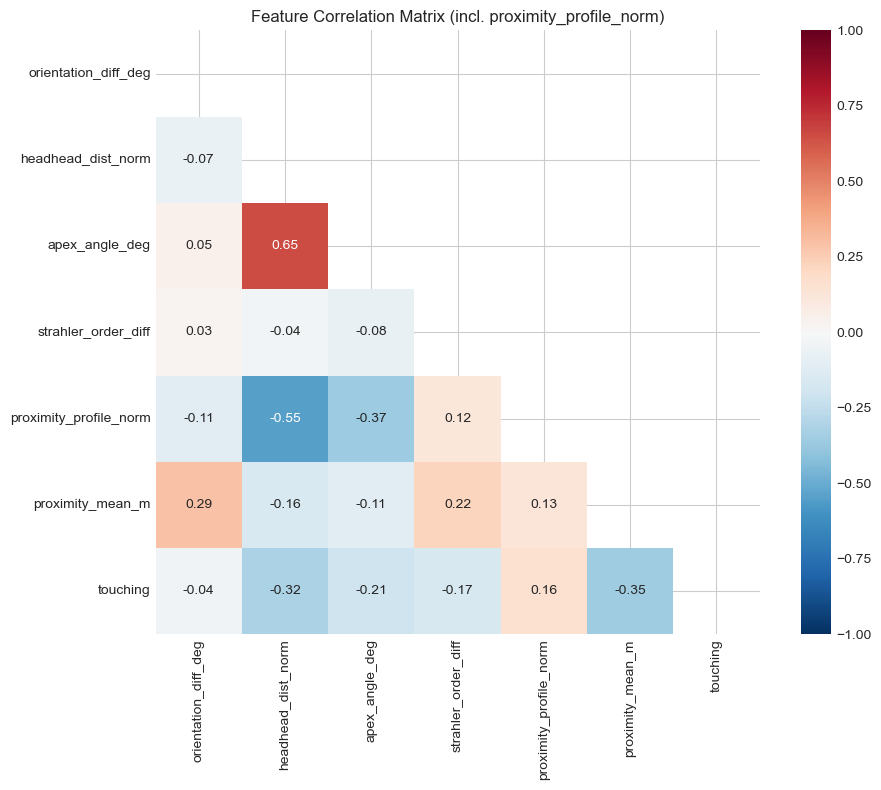


=== Correlation with target (touching) ===
proximity_mean_m         -0.352001
headhead_dist_norm       -0.320215
apex_angle_deg           -0.208545
strahler_order_diff      -0.165879
proximity_profile_norm    0.158646
orientation_diff_deg     -0.039870
Name: touching, dtype: float64


In [8]:
corr_cols = [f for f in available if f in df_explore.columns] + ["touching"]
corr_df = df_explore[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix (incl. proximity_profile_norm)")
plt.tight_layout()
plt.show()

print("\n=== Correlation with target (touching) ===")
target_corr = corr_df["touching"].drop("touching").sort_values(key=abs, ascending=False)
print(target_corr)

## 5. Quick Retrain Comparison

Compare baseline model (4 features) vs augmented model (+proximity_profile_norm).
Uses GroupKFold CV with outlet groups to prevent leakage.

In [9]:
BASELINE_FEATURES = [
    "orientation_diff_deg",
    "headhead_dist_norm",
    "apex_angle_deg",
    "strahler_order_diff",
]
AUGMENTED_FEATURES = BASELINE_FEATURES + ["proximity_profile_norm"]

# Use whichever dataset has touching labels
df_model = df_explore.dropna(subset=["touching", "basin", "outlet"]).copy()
df_model["outlet_group"] = df_model["basin"] + "__" + df_model["outlet"].astype(str)
y = df_model["touching"].astype(int)
outlet_groups = df_model["outlet_group"]

scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "precision": "precision", "recall": "recall"}
gkf = GroupKFold(n_splits=5)

results = {}
for name, feats in [("baseline", BASELINE_FEATURES), ("+ proximity", AUGMENTED_FEATURES)]:
    avail_feats = [f for f in feats if f in df_model.columns]
    if len(avail_feats) < len(feats):
        missing_f = set(feats) - set(avail_feats)
        print(f"Skipping '{name}': missing features {missing_f}")
        continue

    X = df_model[avail_feats]
    n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
    model = XGBClassifier(
        scale_pos_weight=n_neg / n_pos,
        n_estimators=200, max_depth=4, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric="aucpr", tree_method="hist",
    )
    cv = cross_validate(model, X, y, groups=outlet_groups, cv=gkf, scoring=scoring, n_jobs=-1)
    results[name] = cv
    print(f"\n=== {name} (features={avail_feats}) ===")
    for metric in scoring:
        vals = cv[f"test_{metric}"]
        print(f"  {metric:>12s}: {vals.mean():.3f} ± {vals.std():.3f}")


=== baseline (features=['orientation_diff_deg', 'headhead_dist_norm', 'apex_angle_deg', 'strahler_order_diff']) ===
       roc_auc: 0.766 ± 0.010
        pr_auc: 0.712 ± 0.021
     precision: 0.595 ± 0.013
        recall: 0.661 ± 0.021

=== + proximity (features=['orientation_diff_deg', 'headhead_dist_norm', 'apex_angle_deg', 'strahler_order_diff', 'proximity_profile_norm']) ===
       roc_auc: 0.777 ± 0.009
        pr_auc: 0.720 ± 0.020
     precision: 0.604 ± 0.012
        recall: 0.680 ± 0.017


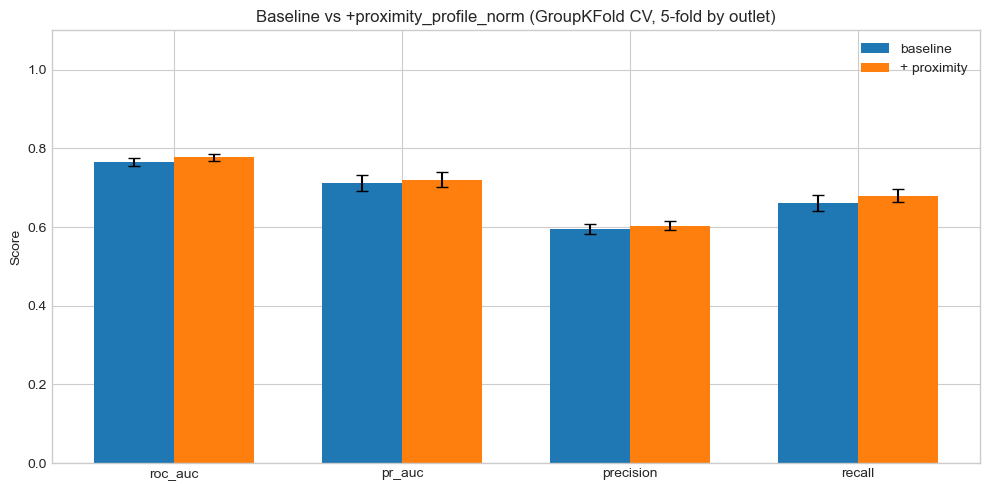

In [10]:
# Summary bar chart comparing the two models
if len(results) == 2:
    metrics = ["roc_auc", "pr_auc", "precision", "recall"]
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (name, cv) in enumerate(results.items()):
        means = [cv[f"test_{m}"].mean() for m in metrics]
        stds  = [cv[f"test_{m}"].std() for m in metrics]
        ax.bar(x + i * width, means, width, yerr=stds, label=name, capsize=4)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.1)
    ax.set_title("Baseline vs +proximity_profile_norm (GroupKFold CV, 5-fold by outlet)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. n_samples Sensitivity

Sweep `n_proximity_samples` values and compare KS statistics for `proximity_profile_norm`.

**Only runs if the DEM is available** (requires Inyo basin DEM).

n_samples=  3: KS=0.446, NaN rate=0.0%
n_samples=  5: KS=0.446, NaN rate=0.0%
n_samples= 10: KS=0.446, NaN rate=0.0%
n_samples= 20: KS=0.446, NaN rate=0.0%
n_samples= 50: KS=0.446, NaN rate=0.0%


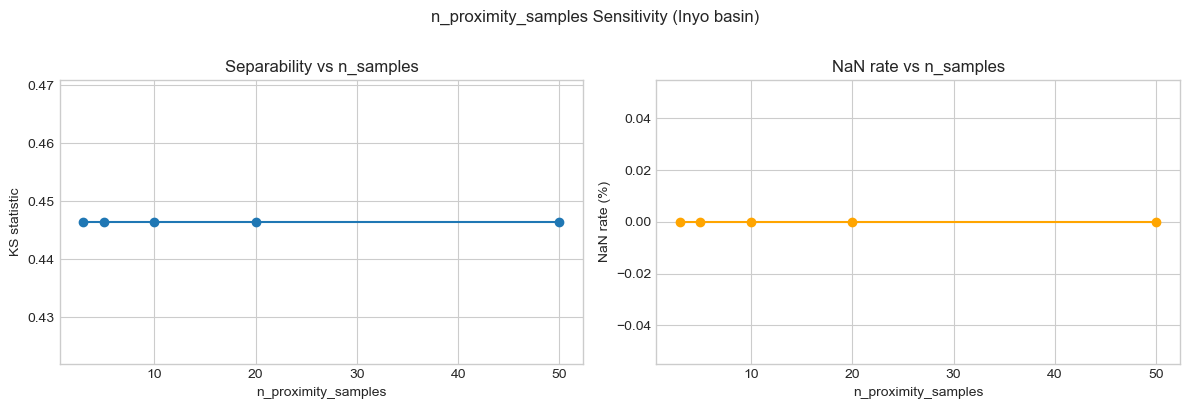

In [11]:
if SANITY_OK:
    n_samples_sweep = [3, 5, 10, 20, 50]
    sweep_results = []

    for n in n_samples_sweep:
        geom_an_n = GeometricFeaturesAnalyzer(
            s, dem, lat=config["lat"], n_proximity_samples=n, node_orders=node_orders
        )
        rows = []
        for outlet_id in outlets:
            pairs, _ = first_meet_pairs_for_outlet(s, outlet_id)
            if not pairs:
                continue
            asym_df_ = asym_an.evaluate_pairs_for_outlet(outlet_id, pairs)
            geom_df_ = geom_an_n.evaluate_pairs_for_outlet(outlet_id, pairs, asymmetry_df=asym_df_)
            rows.append(geom_df_)

        if not rows:
            continue
        geom_all = pd.concat(rows, ignore_index=True)

        # Merge touching labels from inyo_df
        merge_keys = ["outlet", "confluence", "head_1", "head_2"]
        merged = geom_all.merge(
            inyo_df[merge_keys + ["touching"]].dropna(),
            on=merge_keys, how="inner",
        )

        d0 = merged.loc[merged["touching"] == False, "proximity_profile_norm"].dropna()
        d1 = merged.loc[merged["touching"] == True, "proximity_profile_norm"].dropna()
        if len(d0) >= 2 and len(d1) >= 2:
            ks, _ = ks_2samp(d0, d1)
        else:
            ks = float("nan")
        nan_rate = merged["proximity_profile_norm"].isna().mean()
        sweep_results.append({"n_samples": n, "KS_stat": ks, "nan_rate": nan_rate})
        print(f"n_samples={n:>3d}: KS={ks:.3f}, NaN rate={nan_rate:.1%}")

    df_sweep = pd.DataFrame(sweep_results)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_sweep["n_samples"], df_sweep["KS_stat"], marker="o")
    axes[0].set_xlabel("n_proximity_samples")
    axes[0].set_ylabel("KS statistic")
    axes[0].set_title("Separability vs n_samples")
    axes[1].plot(df_sweep["n_samples"], df_sweep["nan_rate"] * 100, marker="o", color="orange")
    axes[1].set_xlabel("n_proximity_samples")
    axes[1].set_ylabel("NaN rate (%)")
    axes[1].set_title("NaN rate vs n_samples")
    plt.suptitle("n_proximity_samples Sensitivity (Inyo basin)", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: DEM not available.")